### Import Libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf



###  Loadthe Fashion MNIST dataset
Fashion MNIST is a dataset of Zalando's article images, consisting of 60,000 training examples and 10,000 test examples. Each example is a 28x28 grayscale image,associated with a label from 10 classes. 

In [41]:
fashion_mnist_dataset = tf.keras.datasets.fashion_mnist

In [42]:
fashion_mnist_dataset

<module 'keras.datasets.fashion_mnist' from 'C:\\Users\\Shrabani P\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\keras\\datasets\\fashion_mnist\\__init__.py'>

In [43]:
(x_train, y_train), (x_test, y_test) = fashion_mnist_dataset.load_data()

In [44]:
print(f"shape of the x_train: {x_train.shape}")
print(f"shape of the x_test: {x_test.shape}")
print(f"shape of the y_train: {y_train.shape}")
print(f"shape of the y_test: {y_test.shape}")

shape of the x_train: (60000, 28, 28)
shape of the x_test: (10000, 28, 28)
shape of the y_train: (60000,)
shape of the y_test: (10000,)


In [45]:
# Reshape from (60000, 28, 28) to (60000, 28, 28, 1)
x_train = x_train.reshape(len(x_train), 28, 28, 1)
x_test = x_test.reshape(len(x_test), 28, 28, 1)
y_train = y_train.reshape(len(y_train), 1)
y_test =y_test.reshape(len(y_test), 1)


In [46]:
print(f"shape of the x_train: {x_train.shape}")
print(f"shape of the x_test: {x_test.shape}")
print(f"shape of the y_train: {y_train.shape}")
print(f"shape of the y_test: {y_test.shape}")

shape of the x_train: (60000, 28, 28, 1)
shape of the x_test: (10000, 28, 28, 1)
shape of the y_train: (60000, 1)
shape of the y_test: (10000, 1)


In [47]:
print(x_train[0,:])

[[[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  1]
  [  0]
  [  0]
  [ 13]
  [ 73]
  [  0]
  [  0]
  [  1]
  [  4]
  [  0]
  [  0]
  [  0]
  [  0]
  [  1]
  [  1]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]


### Visualize different samples from the dataset

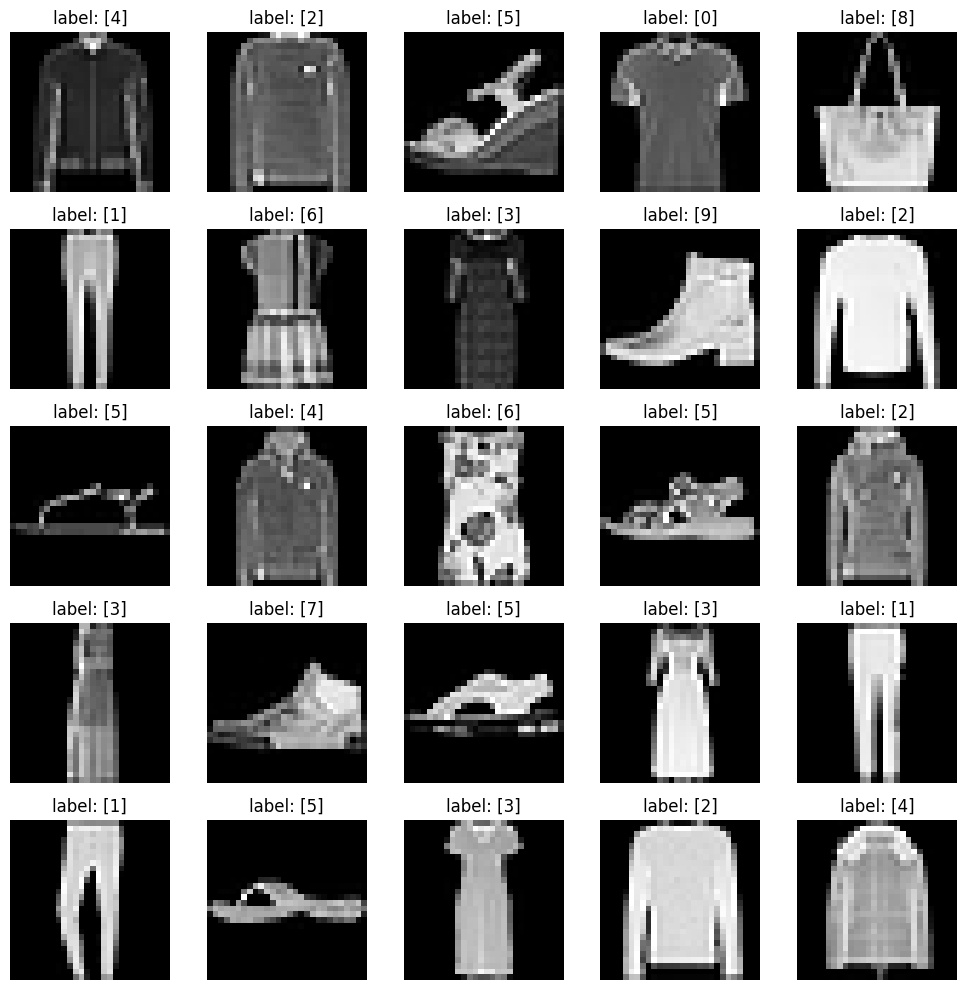

In [48]:
num_images =25
random_images = np.random.choice(len(x_train),num_images, replace = False)

plt.figure(figsize=(10,10))

for idx, i in enumerate(random_images):
    plt.subplot(5,5, idx+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()
    

### Normalization

In [49]:
x_train_normalized = x_train/255
x_test_normalized = x_test/255

In [50]:
print(x_train.min())
print(x_train.max())

0
255


In [51]:
print(x_train_normalized.min())
print(x_test_normalized.max())

0.0
1.0


In [52]:
print(x_train_normalized[0, :])

[[[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0. 

### Convert the output labels to categorical format for classification

In [53]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

In [54]:
y_train_cat.shape

(60000, 10)

In [55]:
y_test_cat.shape

(10000, 10)

### Build the model

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense 
import tensorflow.keras.backend as K

In [57]:
K.clear_session()

In [60]:
model = Sequential()

In [61]:

## adding the 1st convolutional layer

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(2,2))

## adding the 2nd convolutional layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

## adding ANN block on the top of CNN block
model.add(Flatten())
model.add(Dense(256, activation ='relu'))
model.add(Dense(128, activation = 'relu'))
model.add(Dense(10, activation ='softmax'))


In [62]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │         409,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 462,858 (1.77 MB)

 Trainable params: 462,858 (1.77 MB)

 Non-trainable params: 0 (0.00 B)

### Compile and train the model

In [63]:
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics= ['accuracy'])

In [64]:
history_01 = model.fit(x_train_normalized, y_train_cat, epochs=10, validation_data=(x_test_normalized, y_test_cat))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.8328 - loss: 0.4505 - val_accuracy: 0.8770 - val_loss: 0.3435
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 22ms/step - accuracy: 0.8907 - loss: 0.2959 - val_accuracy: 0.8872 - val_loss: 0.3137
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9065 - loss: 0.2507 - val_accuracy: 0.8998 - val_loss: 0.2712
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9200 - loss: 0.2159 - val_accuracy: 0.8941 - val_loss: 0.2848
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.9281 - loss: 0.1884 - val_accuracy: 0.9040 - val_loss: 0.2611
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9373 - loss: 0.1663 - val_accuracy: 0.9105 - val_loss: 0.2638
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.9461 - loss: 0.1430 - val_accuracy: 0.9106 - val_loss: 0.2756
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9518 -

### Training vs. Validation accuracy acroos Epochs

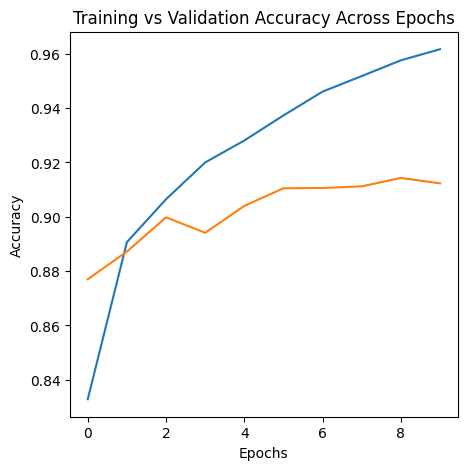

In [65]:
plt.figure(figsize=(5,5))
plt.plot(history_01.history['accuracy'], label =['Training Accuracy'])
plt.plot(history_01.history['val_accuracy'], label =['Validation Accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy Across Epochs')
plt.show()

In [66]:
## Predicted Probabilities
y_pred_prob = model.predict(x_test_normalized)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [67]:
# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

In [68]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)


[[848   0  23  13   3   1 110   0   2   0]
 [  7 966   4  13   7   0   3   0   0   0]
 [ 18   0 909   6  28   0  39   0   0   0]
 [ 19   3  13 928  16   1  18   0   1   1]
 [  2   0  86  31 818   0  63   0   0   0]
 [  0   0   0   0   0 984   0  11   1   4]
 [ 76   0  79  24  57   0 760   0   4   0]
 [  0   0   0   0   0   7   0 983   0  10]
 [  6   0   7   3   3   4   6   4 965   2]
 [  1   0   0   0   0   3   0  34   0 962]]


### Analysis of Confusion Matrix (Fashion-MNIST)

The confusion matrix confirms that the CNN performs robustly on the Fashion-MNIST dataset, achieving high accuracy for most classes. Misclassifications are largely confined to categories with strong visual similarity, particularly among different types of upper-body garments. This behavior is consistent with known challenges of the dataset and reflects effective feature learning by the model.

### Check random 10 Predictions with Actual


In [69]:
y_pred.shape

(10000,)

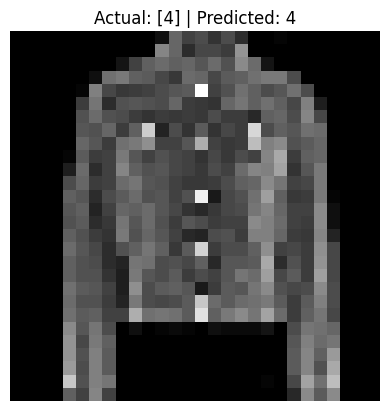

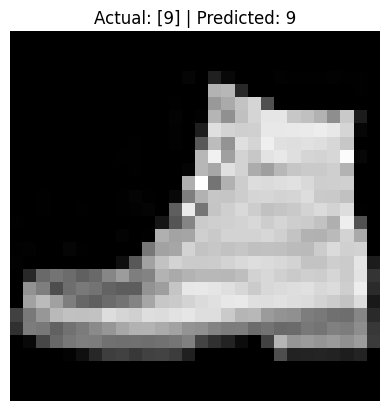

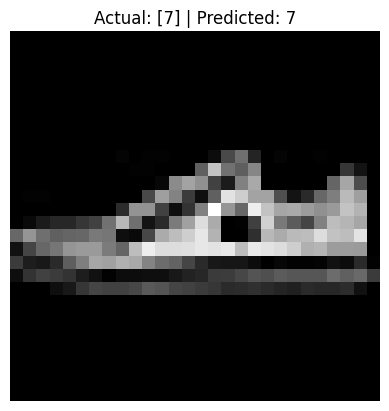

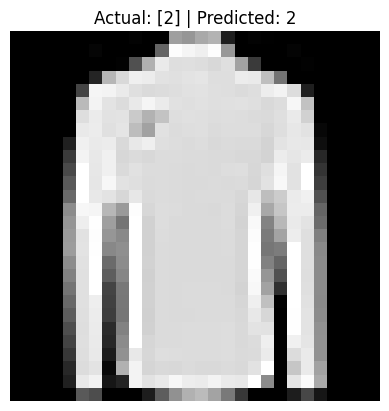

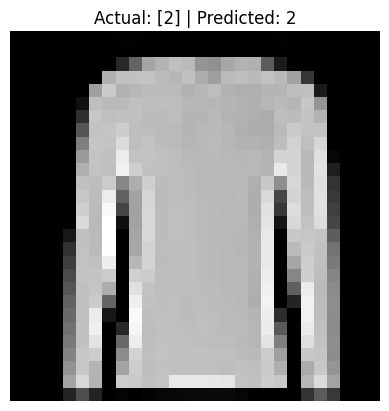

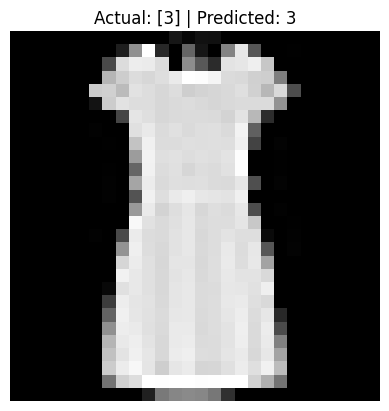

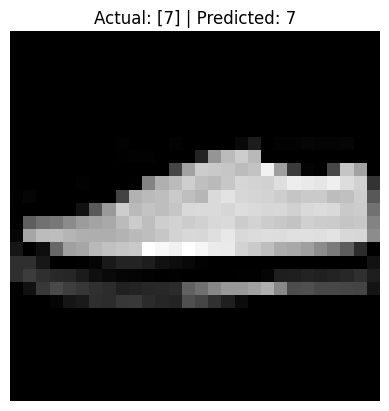

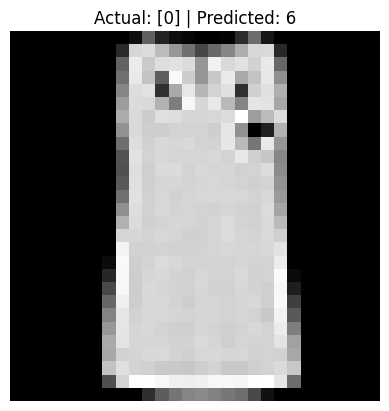

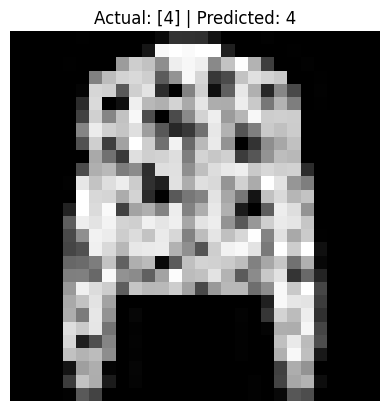

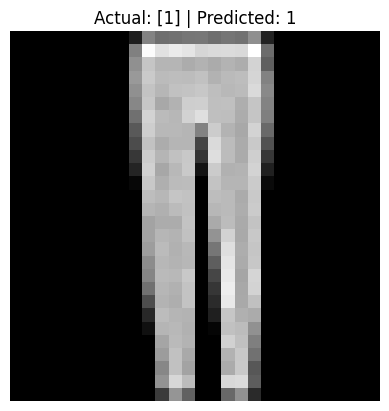

In [70]:
num_images = 10
random_images = np.random.choice(len(x_test_normalized), num_images, replace = False)

for i in random_images:
    plt.imshow(x_test_normalized[i],cmap='gray')
    plt.title(f"Actual: {y_test[i]} | Predicted: {y_pred[i]}")
    plt.axis('off')
    plt.show()

### Observation: Model Prediction Performance on Fashion-MNIST

When evaluating the trained model on 10 randomly selected test images from the Fashion-MNIST dataset, the model correctly predicted 9 out of 10 images, resulting in an observed accuracy of 90% on this sample. This indicates that the model has learned discriminative features effectively and is able to generalize well to unseen data.

The single misclassification can be attributed to the visual similarity between certain apparel categories in Fashion-MNIST, where overlapping shapes and textures commonly lead to ambiguity. Overall, this result demonstrates strong model performance and suggests that the convolutional architecture is well-suited for clothing image classification.

### Model Evaluation and Analysis: Use TensorBoard (Keras)


In [71]:
from tensorflow.keras.callbacks import TensorBoard
import datetime

log_dir = "logs/fashion_mnist/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_cb = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

### Train the model with TensorBoard

In [73]:
history_02 = model.fit(x_train_normalized, y_train_cat, epochs=10, validation_data=(x_test_normalized, y_test_cat), callbacks=[tensorboard_cb], verbose=1)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9669 - loss: 0.0865 - val_accuracy: 0.9130 - val_loss: 0.3260
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.9703 - loss: 0.0777 - val_accuracy: 0.9125 - val_loss: 0.3611
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 21ms/step - accuracy: 0.9729 - loss: 0.0696 - val_accuracy: 0.9143 - val_loss: 0.3584
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.9757 - loss: 0.0644 - val_accuracy: 0.9128 - val_loss: 0.4200
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 22ms/step - accuracy: 0.9784 - loss: 0.0573 - val_accuracy: 0.9139 - val_loss: 0.4258
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9801 - loss: 0.0529 - val_accuracy: 0.9068 - val_loss: 0.4450
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.9820 - loss: 0.0488 - val_accuracy: 0.9096 - val_loss: 0.4712
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 19ms/step - accuracy: 0.9839 -

### Training vs. Validation accuracy acroos Epochs

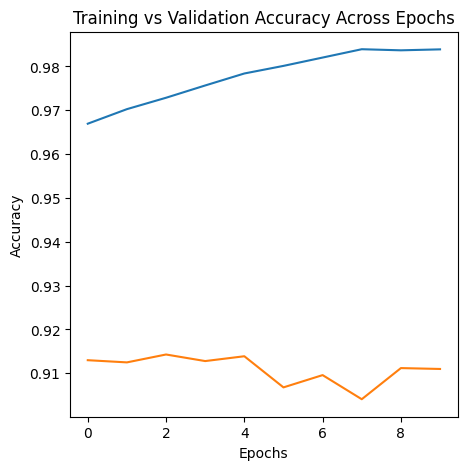

In [74]:
plt.figure(figsize=(5,5))
plt.plot(history_02.history['accuracy'], label =['Training Accuracy'])
plt.plot(history_02.history['val_accuracy'], label =['Validation Accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy Across Epochs')
plt.show()

In [75]:
### save the model
model.save("fashion_mnist_cnn.keras")

In [76]:
from tensorflow.keras.models import load_model

loaded_model = load_model("fashion_mnist_cnn.keras")

In [77]:
loaded_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │         409,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,388,576 (5.30 MB)

 Trainable params: 462,858 (1.77 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 925,718 (3.53 MB)

In [78]:
print("Original model parameters:", model.count_params())
print("Loaded model parameters:", loaded_model.count_params())

Original model parameters: 462858
Loaded model parameters: 462858


### Observation

The original model and the loaded model both have 462,858 parameters, indicating that the model was saved and restored correctly and completely. The identical parameter counts confirm that the architecture and all learned weights of the original model have been preserved without any loss or modification during the saving and loading process.

In [79]:
for w1, w2 in zip(model.get_weights(), loaded_model.get_weights()):
    print(np.allclose(w1, w2))

True
True
True
True
True
True
True
True
True
True


### Observation

All comparisons returned True, indicating that the weights of the original model and the loaded model are numerically identical. This confirms that the trained model’s learned parameters were saved and restored without any alteration or loss of precision.